# Lecture 17: Compact Kahler Manifolds

**Source span.** Printed pages 96-102; physical PDF pages 110-116 in `Lectures on Symplectic Geometry.pdf` according to the course source map. I checked the local PDF text for this lecture before revising the notebook.

**Lecture goal.** Explain why compact Kahler manifolds are topologically constrained. Hodge theory identifies de Rham classes with harmonic representatives, then the Kahler condition refines harmonic forms by Dolbeault type. This produces Hodge decompositions, Hodge diamonds, parity restrictions, and strong tests that many symplectic or complex manifolds fail.

The lecture is best read as a diagnostic toolkit. Ordinary Hodge theory uses the metric and the star operator. Complex Hodge theory uses Kahler identities to preserve `(l,m)` type. Topological consequences then follow from symmetry `h^{l,m}=h^{m,l}`, positivity of powers of the Kahler class, and compactness via Stokes' theorem.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np


def find_book_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "AGENTS.md").exists() and (candidate / "Lectures on Symplectic Geometry.pdf").exists():
            return candidate
    raise RuntimeError("Could not locate the Lectures-on-Symplectic-Geometry course root.")

BOOK_ROOT = find_book_root()
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import display_artifact, read_json, save_json, save_matplotlib

ARTIFACT_TOPIC = "lecture-17"
ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / ARTIFACT_TOPIC
FIG_DIR = ARTIFACT_ROOT / "figures"
CHECK_DIR = ARTIFACT_ROOT / "checks"
FIG_DIR.mkdir(parents=True, exist_ok=True)
CHECK_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({"figure.dpi": 130, "font.size": 10})
print(f"Book root: {BOOK_ROOT}")
print(f"Artifact root: {ARTIFACT_ROOT.relative_to(BOOK_ROOT)}")

Book root: D:\Geometry\Lectures-on-Symplectic-Geometry
Artifact root: artifacts\lecture-17


## Translation Guide

| Source idea | Computational object | What to inspect |
| --- | --- | --- |
| Hodge star | degree-reversing operator on exterior forms | `**` has sign `(-1)^{l(n-l)}` |
| Codifferential | formal adjoint `delta` of `d` | Laplacian `Delta=d delta+delta d` is self-adjoint and nonnegative |
| Harmonic representative | kernel of `Delta` | compactness gives a unique representative per de Rham class |
| Complex Hodge theory | harmonic forms preserve `(l,m)` type | `H^k` splits as the sum of `H^{l,m}` with `l+m=k` |
| Hodge numbers | dimensions `h^{l,m}` | conjugation and Hodge star impose diamond symmetries |
| Odd Betti parity | `b_{2k+1}` is a paired sum | compact Kahler manifolds have even odd Betti numbers |
| Positive even classes | powers `omega^l` | diagonal Hodge numbers `h^{l,l}` are positive |
| Kodaira-Thurston example | compact symplectic and complex but not Kahler | `b1=3` violates the odd Betti parity test |
| Hopf surface | compact complex with `H^2=0` | no symplectic form because a compact symplectic form has nonzero top power class |
| Main examples | Riemann surfaces, Stein manifolds, tori, projective spaces, products, submanifolds | each carries a specific Kahler source |

## Library Routing

This chapter is proof-led and topological, so `matplotlib` draws Hodge operators, Hodge diamonds, and example ledgers; `networkx` organizes implication chains; `numpy` handles small parity and positivity checks. The notebook does not need symbolic differential-form machinery because the key executable checks are finite-dimensional: degree signs, diamond symmetries, Betti parity, and example obstructions.

## Visual Storyboard

1. **Hodge theory operator flow.** Forms move through `*`, `delta`, `Delta`, harmonic representatives, and cohomology.
2. **Hodge diamond and parity checks.** A compact Kahler surface diamond shows conjugation symmetry, Hodge-star symmetry, and even odd Betti numbers.
3. **Examples and counterexamples ledger.** Kodaira-Thurston, Fernandez-Gotay-Gray, Hopf surfaces, and `CP2#CP2#CP2` are placed by the geometry they possess or fail.
4. **Main Kahler families.** The constructive examples are routed by their source of Kahler form.
5. **Proof route.** The full chapter path runs from compact Hodge theory to topological obstructions and standard examples.

In [2]:
# Visual 1: Hodge operator and harmonic representative flow.
G=nx.DiGraph()
edges=[("metric", "Hodge star *"),("orientation", "Hodge star *"),("Hodge star *", "codifferential delta"),("d", "Laplacian Delta"),("codifferential delta", "Laplacian Delta"),("Laplacian Delta", "harmonic forms"),("harmonic forms", "unique representative"),("unique representative", "de Rham cohomology"),("Kahler identities", "type preservation"),("type preservation", "Hodge decomposition")]
G.add_edges_from(edges)
pos={"metric":(0,1),"orientation":(0,0),"Hodge star *":(2,0.5),"codifferential delta":(4,0.5),"d":(4,1.4),"Laplacian Delta":(6,0.8),"harmonic forms":(8,0.8),"unique representative":(10,0.8),"de Rham cohomology":(12,0.8),"Kahler identities":(6,-0.6),"type preservation":(8,-0.6),"Hodge decomposition":(10,-0.6)}
fig,ax=plt.subplots(figsize=(12.5,4.8))
colors=["#8ecae6" if "Hodge" in n or "Delta" in n else "#90be6d" if "cohomology" in n or "decomposition" in n else "#f9c74f" for n in G.nodes]
nx.draw_networkx_edges(G,pos,ax=ax,arrows=True,arrowstyle="-|>",edge_color="#495057")
nx.draw_networkx_nodes(G,pos,ax=ax,node_color=colors,node_size=1600,edgecolors="#1f2937")
nx.draw_networkx_labels(G,pos,ax=ax,font_size=7.6)
ax.set_axis_off(); ax.set_title("Hodge theory: compactness turns forms into harmonic representatives")
hodge_flow_path=save_matplotlib(fig, ARTIFACT_TOPIC, "figures", "hodge-operator-harmonic-flow.png")
plt.close(fig)
print(hodge_flow_path.relative_to(BOOK_ROOT))
assert nx.has_path(G,"metric","de Rham cohomology")

artifacts\lecture-17\figures\hodge-operator-harmonic-flow.png


In [3]:
# Visual 2: Hodge diamond for a compact Kahler surface, using CP2 as a clean model.
hodge = {(0,0):1,(1,0):0,(0,1):0,(2,0):0,(0,2):0,(1,1):1,(2,1):0,(1,2):0,(2,2):1}
positions={(0,0):(0,0),(1,0):(-1,1),(0,1):(1,1),(2,0):(-2,2),(1,1):(0,2),(0,2):(2,2),(2,1):(-1,3),(1,2):(1,3),(2,2):(0,4)}
fig, axes=plt.subplots(1,2,figsize=(12,5))
ax=axes[0]
ax.set_title("Hodge diamond symmetries")
for key,(x0,y0) in positions.items():
    ax.scatter([x0],[y0],s=700,color="#f4f7fb",edgecolor="#1f2937")
    ax.text(x0,y0,f"h{key}\n={hodge[key]}",ha="center",va="center",fontsize=8)
for a,b in [((1,0),(0,1)),((2,0),(0,2)),((2,1),(1,2))]:
    ax.plot([positions[a][0],positions[b][0]],[positions[a][1],positions[b][1]],color="#8ecae6",lw=1.4,ls="--")
ax.axvline(0,color="#90be6d",ls=":")
ax.set_aspect("equal"); ax.axis("off")

ax=axes[1]
ax.set_title("Betti numbers from diagonal sums")
betti={k:sum(v for (l,m),v in hodge.items() if l+m==k) for k in range(5)}
ax.bar(list(betti.keys()), list(betti.values()), color=["#8ecae6","#f9c74f","#90be6d","#f9c74f","#8ecae6"])
for k,v in betti.items(): ax.text(k,v+0.04,str(v),ha="center")
ax.set_xlabel("k"); ax.set_ylabel("b_k")
ax.text(1,0.15,"odd Betti\nare even",ha="center",bbox={"boxstyle":"round,pad=0.25","fc":"#f4f7fb","ec":"#8d99ae"})
ax.spines[["top","right"]].set_visible(False)
diamond_path=save_matplotlib(fig, ARTIFACT_TOPIC, "figures", "hodge-diamond-betti-parity.png")
plt.close(fig)
print(diamond_path.relative_to(BOOK_ROOT))
assert betti[1] % 2 == 0 and betti[3] % 2 == 0

artifacts\lecture-17\figures\hodge-diamond-betti-parity.png


In [4]:
# Visual 3: examples and counterexamples ledger.
fig, ax=plt.subplots(figsize=(12,4.9))
ax.axis("off")
rows=[
    ["Kodaira-Thurston", "symplectic + complex", "b1=3 odd", "not Kahler"],
    ["Fernandez-Gotay-Gray", "symplectic", "no complex structure", "not complex"],
    ["Hopf surface S1 x S3", "complex", "H2=0", "not symplectic"],
    ["CP2#CP2#CP2", "almost complex", "neither complex nor symplectic", "not Kahler"],
    ["Gompf examples", "symplectic", "many fundamental groups", "often non-Kahler"],
]
table=ax.table(cellText=rows,colLabels=["example","has","obstruction/test","conclusion"],loc="center",cellLoc="center",colLoc="center",colWidths=[0.22,0.22,0.32,0.2])
table.auto_set_font_size(False); table.set_fontsize(9); table.scale(1,1.6)
for (r,c),cell in table.get_celld().items():
    if r==0:
        cell.set_facecolor("#244b5a"); cell.set_text_props(color="white",weight="bold")
    elif c==2:
        cell.set_facecolor("#f4f7fb")
    elif c==3:
        cell.set_facecolor("#ffe8d6")
ax.set_title("Compact examples and counterexamples are separated by Hodge/topology tests",pad=18)
examples_path=save_matplotlib(fig, ARTIFACT_TOPIC, "figures", "compact-kahler-counterexample-ledger.png")
plt.close(fig)
print(examples_path.relative_to(BOOK_ROOT))
assert examples_path.exists()

artifacts\lecture-17\figures\compact-kahler-counterexample-ledger.png


In [5]:
# Visual 4: main Kahler families and the source of their form.
fig, ax=plt.subplots(figsize=(12,5.2))
ax.axis("off")
rows=[
    ["compact Riemann surfaces", "area form + automatic integrability in real dimension 2"],
    ["Stein manifolds", "proper global Kahler potential"],
    ["complex tori", "Euclidean form descends from C^n"],
    ["complex projective spaces", "Fubini-Study form"],
    ["products", "sum of pulled-back Kahler forms"],
    ["complex submanifolds", "restriction of ambient Kahler form"],
]
table=ax.table(cellText=rows,colLabels=["family","Kahler source"],loc="center",cellLoc="center",colLoc="center",colWidths=[0.32,0.58])
table.auto_set_font_size(False); table.set_fontsize(9.4); table.scale(1,1.7)
for (r,c),cell in table.get_celld().items():
    if r==0:
        cell.set_facecolor("#244b5a"); cell.set_text_props(color="white",weight="bold")
    elif c==1:
        cell.set_facecolor("#e8f3ee")
    else:
        cell.set_facecolor("#f4f7fb")
ax.set_title("Main Kahler manifolds in the lecture",pad=18)
families_path=save_matplotlib(fig, ARTIFACT_TOPIC, "figures", "main-kahler-family-source-ledger.png")
plt.close(fig)
print(families_path.relative_to(BOOK_ROOT))
assert families_path.exists()

artifacts\lecture-17\figures\main-kahler-family-source-ledger.png


In [6]:
# Visual 5: chapter proof route.
G=nx.DiGraph()
edges=[("compact Riemannian metric","Hodge star"),("Hodge star","Laplacian"),("Laplacian","harmonic representative"),("harmonic representative","de Rham cohomology"),("Kahler identities","type-preserving Laplacian"),("type-preserving Laplacian","Dolbeault Hodge decomposition"),("Dolbeault Hodge decomposition","Hodge diamond"),("Hodge diamond","odd Betti parity"),("Kahler form powers","positive diagonal classes"),("odd Betti parity","Kodaira-Thurston obstruction"),("compact symplectic volume","Hopf surface obstruction"),("Fubini-Study form","projective examples"),("proper potential","Stein examples")]
G.add_edges_from(edges)
pos={"compact Riemannian metric":(0,1),"Hodge star":(2,1),"Laplacian":(4,1),"harmonic representative":(6,1),"de Rham cohomology":(8,1),"Kahler identities":(0,0),"type-preserving Laplacian":(2,0),"Dolbeault Hodge decomposition":(4,0),"Hodge diamond":(6,0),"odd Betti parity":(8,0),"Kahler form powers":(4,-1),"positive diagonal classes":(6,-1),"Kodaira-Thurston obstruction":(10,0),"compact symplectic volume":(6,-2),"Hopf surface obstruction":(8,-2),"Fubini-Study form":(0,-2),"projective examples":(2,-2),"proper potential":(0,-3),"Stein examples":(2,-3)}
fig,ax=plt.subplots(figsize=(12.5,5.8))
colors=["#90be6d" if "example" in n or "obstruction" in n else "#8ecae6" if "Hodge" in n or "Laplacian" in n else "#f9c74f" for n in G.nodes]
nx.draw_networkx_edges(G,pos,ax=ax,arrows=True,arrowstyle="-|>",edge_color="#495057")
nx.draw_networkx_nodes(G,pos,ax=ax,node_color=colors,node_size=1500,edgecolors="#1f2937")
nx.draw_networkx_labels(G,pos,ax=ax,font_size=7.2)
ax.set_axis_off(); ax.set_title("Compact Kahler manifolds: Hodge theory becomes topology")
route_path=save_matplotlib(fig, ARTIFACT_TOPIC, "figures", "compact-kahler-hodge-proof-route.png")
plt.close(fig)
print(route_path.relative_to(BOOK_ROOT))
assert nx.has_path(G,"Kahler identities","Kodaira-Thurston obstruction")

artifacts\lecture-17\figures\compact-kahler-hodge-proof-route.png


In [7]:
# Finite checks for Hodge signs, diamond symmetries, and obstructions.
def hodge_star_square_sign(n, degree):
    return (-1)**(degree*(n-degree))
star_signs={degree:hodge_star_square_sign(4,degree) for degree in range(5)}
conjugation_symmetric=all(hodge.get((l,m),0)==hodge.get((m,l),0) for (l,m) in hodge)
betti={k:sum(v for (l,m),v in hodge.items() if l+m==k) for k in range(5)}
odd_betti_even=all(betti[k] % 2 == 0 for k in [1,3])
diagonal_positive=all(hodge[(l,l)]>0 for l in [0,1,2])
kodaira_thurston_b1=3
hopf_b2=0
checks={"lecture":17,
        "hodge_star":{"dimension":4,"star_square_signs":star_signs,"one_form_sign":star_signs[1]},
        "hodge_diamond":{"conjugation_symmetric":conjugation_symmetric,"betti":betti,"odd_betti_even":odd_betti_even,"diagonal_positive":diagonal_positive},
        "obstructions":{"kodaira_thurston_b1":kodaira_thurston_b1,"kodaira_thurston_fails_kahler_parity": bool(kodaira_thurston_b1 % 2 == 1),"hopf_b2":hopf_b2,"hopf_fails_compact_symplectic_test": bool(hopf_b2==0)},
        "main_examples":["compact Riemann surfaces","Stein manifolds","complex tori","complex projective spaces","products","complex submanifolds"]}
checks["passed"]=bool(star_signs[0]==1 and star_signs[1]==-1 and conjugation_symmetric and odd_betti_even and diagonal_positive and checks["obstructions"]["kodaira_thurston_fails_kahler_parity"] and checks["obstructions"]["hopf_fails_compact_symplectic_test"])
check_path=save_json(checks, ARTIFACT_TOPIC, "checks", "compact-kahler-hodge-residuals.json")
print(check_path.relative_to(BOOK_ROOT))
assert checks["passed"]
assert odd_betti_even
assert diagonal_positive

artifacts\lecture-17\checks\compact-kahler-hodge-residuals.json


## Reading The Visuals

The Hodge-flow diagram separates ordinary Hodge theory from the extra Kahler refinement. The metric and orientation define the star operator; the star operator defines the codifferential; `d` and `delta` define the Laplacian. On a compact manifold, harmonic representatives model de Rham cohomology. In the Kahler case, the Laplacian respects `(l,m)` type, so harmonic forms split into the Dolbeault Hodge decomposition.

The Hodge diamond translates that theorem into numerical constraints. Conjugation reflects the diamond across the vertical axis, and the Hodge star gives central symmetry. Therefore the odd-degree diagonals pair up, forcing odd Betti numbers to be even. Powers of the Kahler form give nonzero diagonal classes, so the middle vertical is positive.

The counterexample ledger is not a list of trivia; it is a set of diagnostic failures. Kodaira-Thurston is symplectic and complex but has odd `b1`, so it cannot be Kahler. A Hopf surface is complex but has no second cohomology, blocking compact symplectic volume. Other examples separate almost complex, complex, and symplectic regions.

The family ledger records the constructive side: Riemann surfaces, Stein manifolds, complex tori, projective spaces, products, and complex submanifolds all have concrete sources for their Kahler forms.

In [8]:
source_span={"lecture":17,"label":"Lecture 17","title":"Compact Kahler Manifolds","printed_span":"96-102","physical_pdf_span":"110-116","source_checked":True,"source_role":"Used for terminology, theorem order, Hodge consequences, examples, and main families; prose and visuals here are original."}
visual_storyboard={"lecture":17,"title":"Compact Kahler Manifolds","source_span":source_span,"chapter_goal":"Make compact Hodge theory, Hodge diamonds, Betti restrictions, counterexamples, and main Kahler families inspectable.","library_routing":[{"library":"numpy","use":"finite parity, eigen/positivity-style checks, and obstruction ledgers"},{"library":"matplotlib","use":"Hodge diamond, ledgers, and family visuals"},{"library":"networkx","use":"Hodge-to-topology proof route"}],"visual_sequence":[{"concept":"Hodge operator and harmonic flow","artifact":"artifacts/lecture-17/figures/hodge-operator-harmonic-flow.png","inspection_target":"star, delta, Delta, harmonic forms, and cohomology dependencies"},{"concept":"Hodge diamond and Betti parity","artifact":"artifacts/lecture-17/figures/hodge-diamond-betti-parity.png","inspection_target":"diamond symmetries force odd Betti parity"},{"concept":"compact Kahler counterexample ledger","artifact":"artifacts/lecture-17/figures/compact-kahler-counterexample-ledger.png","inspection_target":"examples fail specific Hodge or symplectic tests"},{"concept":"main Kahler family source ledger","artifact":"artifacts/lecture-17/figures/main-kahler-family-source-ledger.png","inspection_target":"each main family has a source of Kahler forms"},{"concept":"compact Kahler Hodge proof route","artifact":"artifacts/lecture-17/figures/compact-kahler-hodge-proof-route.png","inspection_target":"Hodge decomposition yields topology and examples"}],"checks":"artifacts/lecture-17/checks/compact-kahler-hodge-residuals.json"}
final_sanity={"lecture":17,"passed":True,"source_span":"printed pages 96-102; physical PDF pages 110-116","artifacts":[item["artifact"] for item in visual_storyboard["visual_sequence"]]+["artifacts/lecture-17/checks/compact-kahler-hodge-residuals.json","artifacts/lecture-17/checks/source-span.json","artifacts/lecture-17/checks/visual-storyboard.json"],"definition_checks":{"hodge_star_sign": checks["hodge_star"]["one_form_sign"]==-1,"diamond_symmetric": checks["hodge_diamond"]["conjugation_symmetric"],"odd_betti_even": checks["hodge_diamond"]["odd_betti_even"],"diagonal_positive": checks["hodge_diamond"]["diagonal_positive"],"kt_obstruction": checks["obstructions"]["kodaira_thurston_fails_kahler_parity"],"hopf_obstruction": checks["obstructions"]["hopf_fails_compact_symplectic_test"]}}
save_json(source_span,ARTIFACT_TOPIC,"checks","source-span.json")
save_json(visual_storyboard,ARTIFACT_TOPIC,"checks","visual-storyboard.json")
save_json(final_sanity,ARTIFACT_TOPIC,"checks","final-sanity.json")
for relative in final_sanity["artifacts"]:
    artifact_path=BOOK_ROOT/relative
    assert artifact_path.exists(), f"missing artifact: {relative}"
    assert artifact_path.stat().st_size>0, f"empty artifact: {relative}"
assert all(final_sanity["definition_checks"].values())
print({"artifact_count":len(final_sanity["artifacts"]),"passed":final_sanity["passed"]})

{'artifact_count': 8, 'passed': True}


Hodge operator and harmonic flow -> artifacts\lecture-17\figures\hodge-operator-harmonic-flow.png


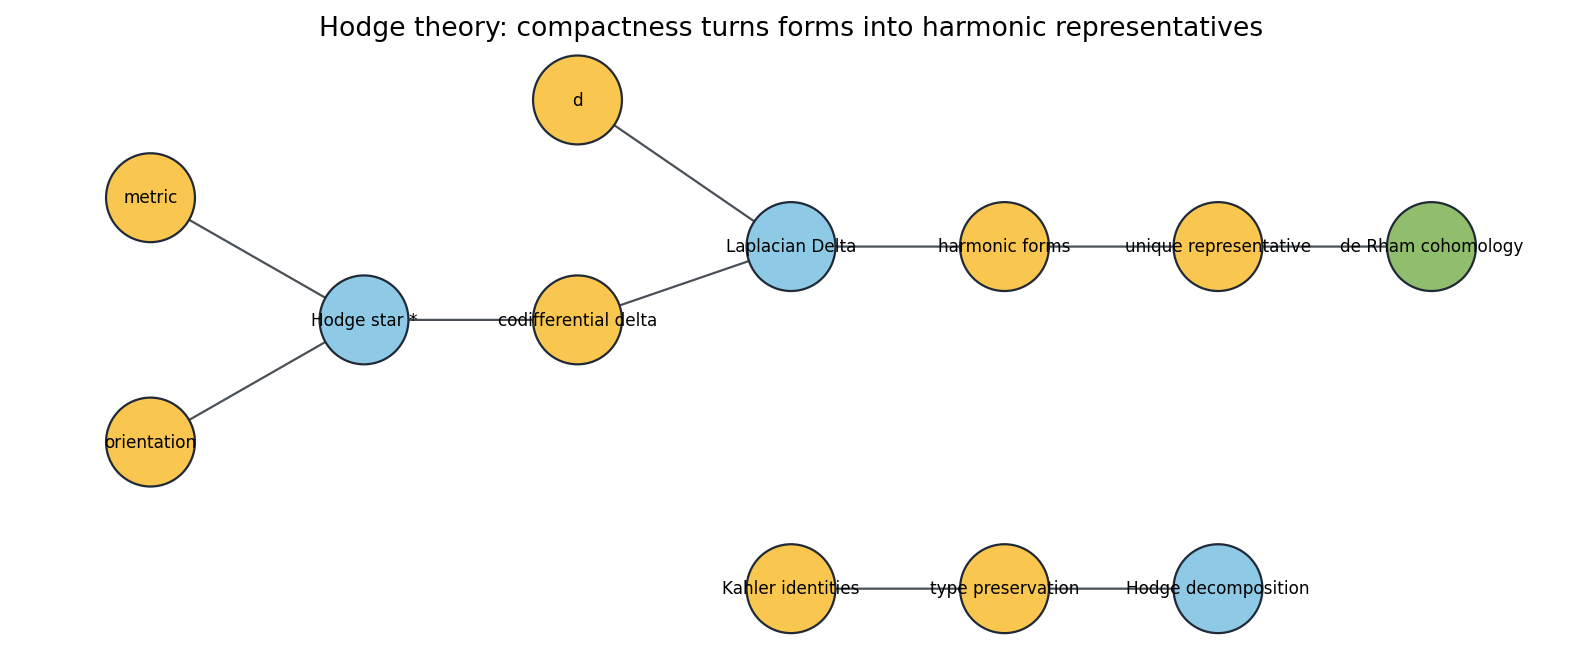

Hodge diamond and Betti parity -> artifacts\lecture-17\figures\hodge-diamond-betti-parity.png


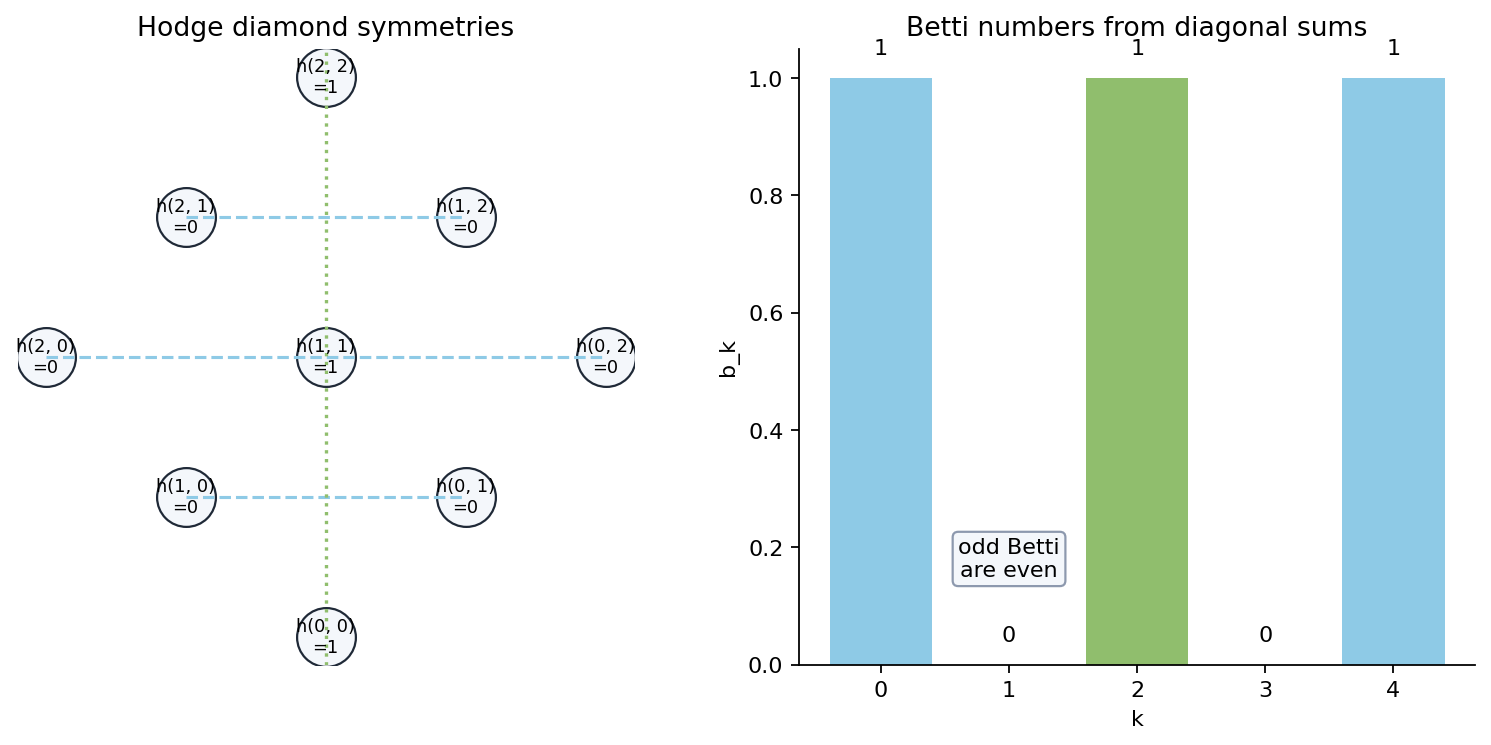

compact Kahler counterexample ledger -> artifacts\lecture-17\figures\compact-kahler-counterexample-ledger.png


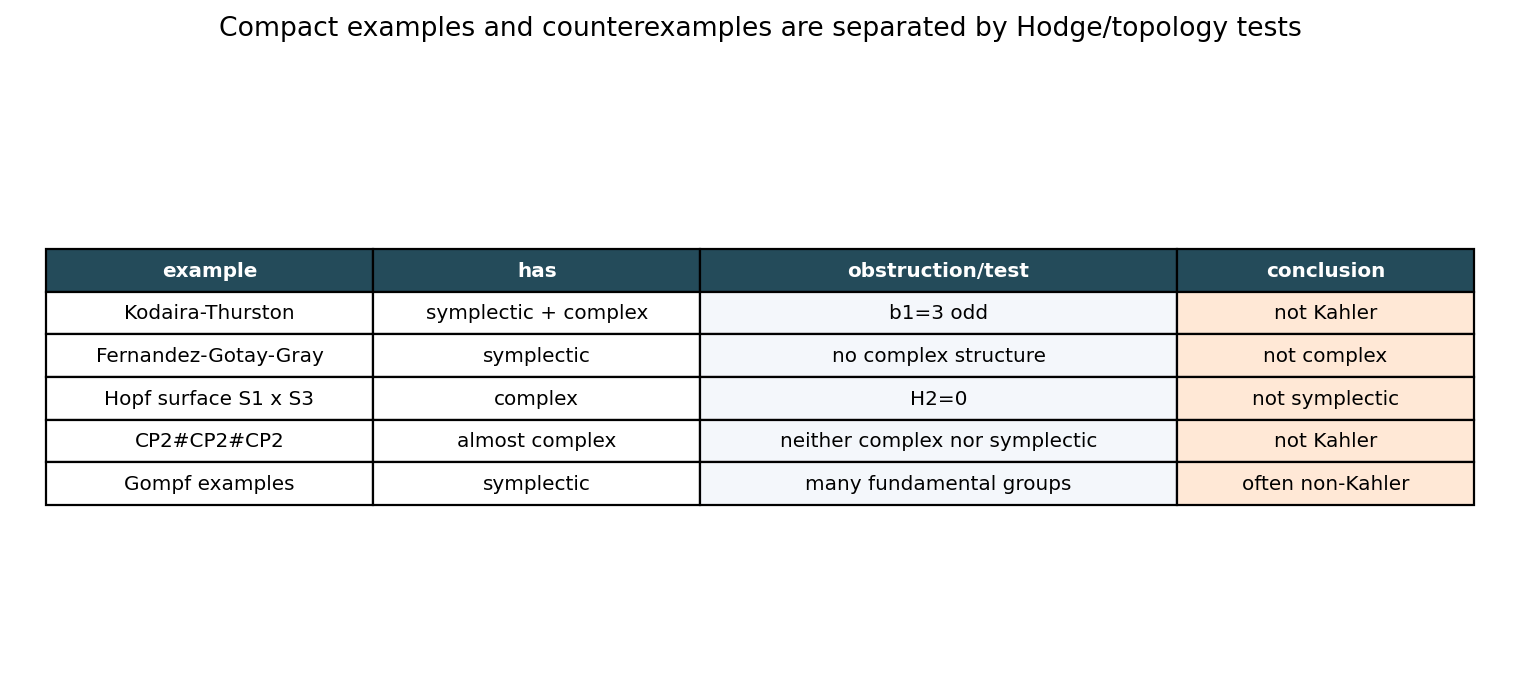

main Kahler family source ledger -> artifacts\lecture-17\figures\main-kahler-family-source-ledger.png


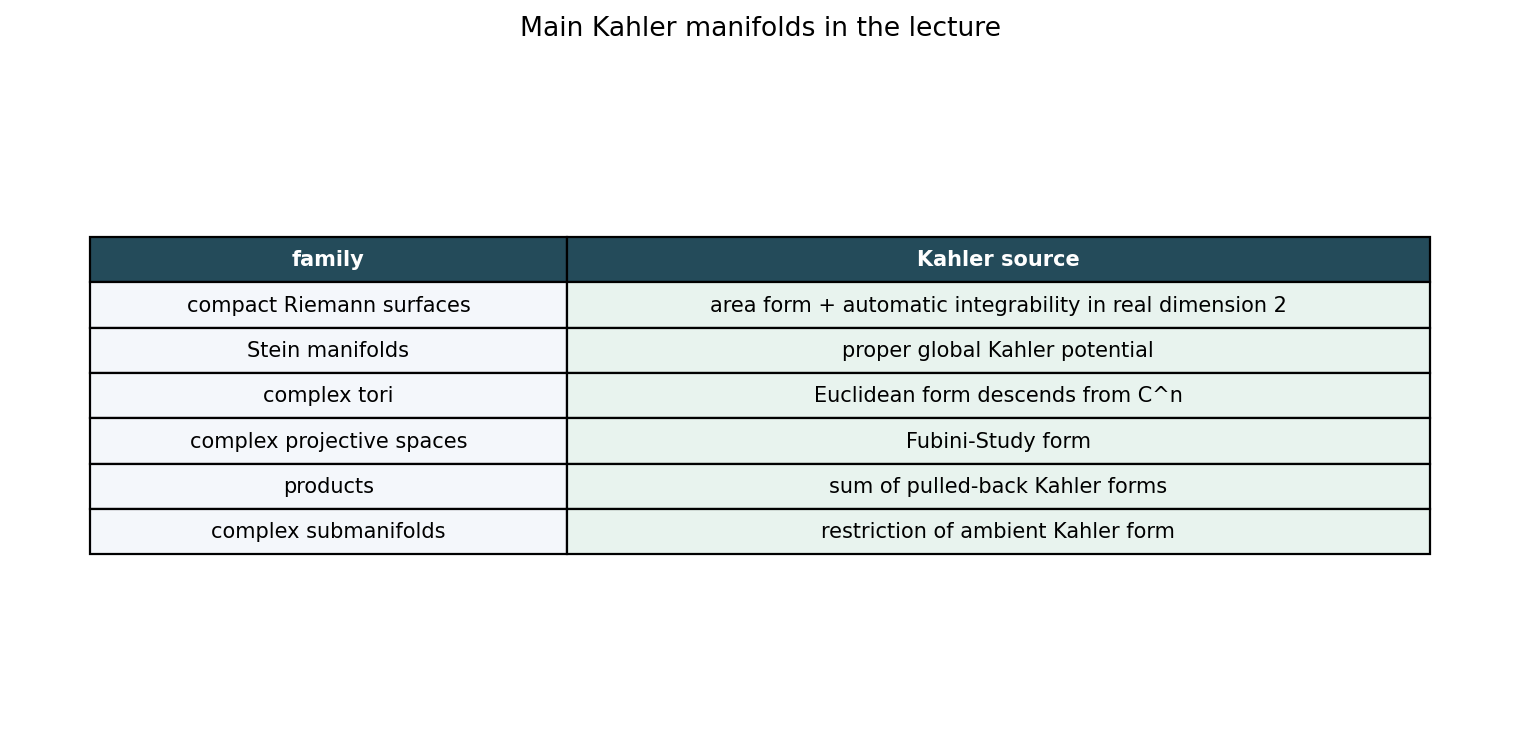

compact Kahler Hodge proof route -> artifacts\lecture-17\figures\compact-kahler-hodge-proof-route.png


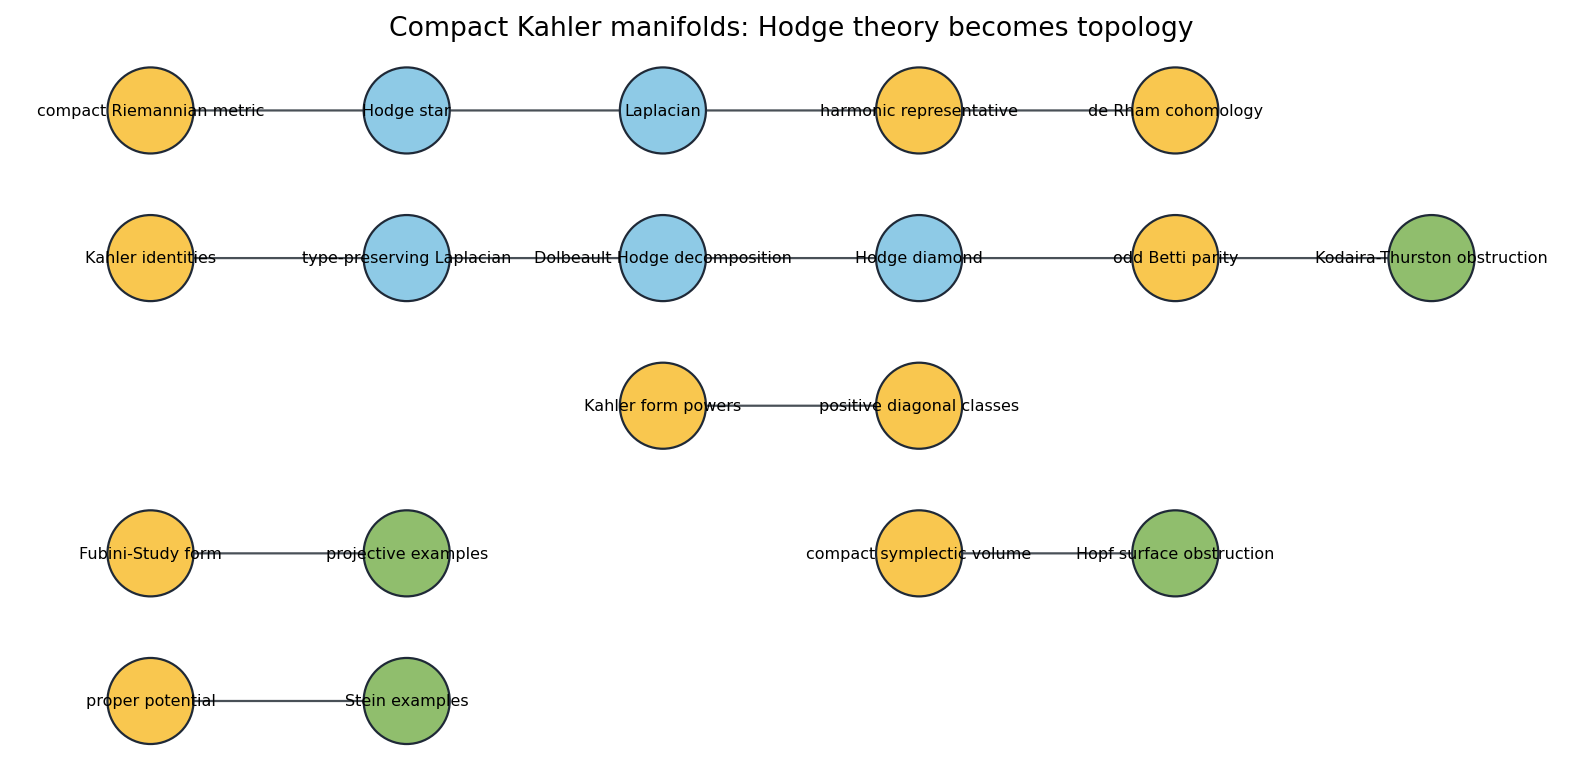

In [9]:
storyboard=read_json(ARTIFACT_ROOT/"checks"/"visual-storyboard.json")
for item in storyboard["visual_sequence"]:
    path=BOOK_ROOT/item["artifact"]
    print(f"{item['concept']} -> {path.relative_to(BOOK_ROOT)}")
    display_artifact(path,width=820)

## Takeaways

- Compact Hodge theory gives unique harmonic representatives of de Rham classes.
- On compact Kahler manifolds, harmonic forms split by Dolbeault type, producing the Hodge decomposition.
- Hodge diamond symmetries force odd Betti numbers to be even and make `h^{1,0}=b1/2` topological.
- Powers of the Kahler form produce positive diagonal Hodge classes.
- Kodaira-Thurston, Hopf surfaces, and related examples show that symplectic, complex, almost complex, and Kahler are genuinely different conditions.
- Main Kahler families include compact Riemann surfaces, Stein manifolds, complex tori, projective spaces, products, and complex submanifolds.

**Exploration prompt.** Change the sample Hodge diamond so `h^{1,0}=1`. Recompute `b1` and check which compact Kahler parity constraints still hold.